# ♻️ RecycleVision: AI-Powered Garbage Classification System

## 📌 Project Overview

RecycleVision is a deep learning-based image classification system designed to automatically identify and categorize waste materials into different recyclable categories. The goal of this project is to support smarter waste management and recycling processes using Artificial Intelligence.

This project uses **Transfer Learning with EfficientNetB0** to classify waste images into six categories.

## 🎯 Objectives

* Build an AI model to classify garbage images.
* Apply transfer learning using EfficientNetB0.
* Handle class imbalance using class weights.
* Evaluate the model using accuracy, classification report, and confusion matrix.
* Deploy the trained model through a **Streamlit web application** for real-time prediction.

## 🗂 Dataset Information

Dataset used: **Garbage Classification Dataset (TrashNet)**

Classes:

* Cardboard
* Glass
* Metal
* Paper
* Plastic
* Trash

Total Images: **2527**

## 🧠 Technologies Used

* Python
* TensorFlow / Keras
* EfficientNetB0
* OpenCV
* NumPy & Pandas
* Matplotlib & Seaborn
* Streamlit

## 📊 Model Performance

* Validation Accuracy: **~83–85%**
* Model Architecture: **EfficientNetB0 (Transfer Learning)**

## 🚀 Project Workflow

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Augmentation
4. Transfer Learning Model (EfficientNetB0)
5. Model Training
6. Fine-Tuning
7. Model Evaluation
8. Streamlit Web App Deployment


##   STEP 1: Required Libraries Import

In [2]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.19.0


## STEP 2: Data Loading / Drive Mount / Dataset Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_dir = "/content/drive/MyDrive/RecycleVision_Project/Garbage classification/"

# Verify dataset path
print("Dataset path:", data_dir)
print("Directory exists:", os.path.exists(data_dir))

Dataset path: /content/drive/MyDrive/RecycleVision_Project/Garbage classification/
Directory exists: True


## Exploratory Data Analysis

In [5]:
# List all classes/folders in the dataset
classes = os.listdir(data_dir)
print("Classes found:", classes)
print("Total number of classes:", len(classes))

Classes found: ['cardboard', 'glass', 'paper', 'metal', 'trash', 'plastic']
Total number of classes: 6


In [6]:
from collections import Counter

# Create a simple generator (only for counting)
datagen = ImageDataGenerator(rescale=1./255)

dataset = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Get labels
labels = dataset.classes

# Count samples per class
count_per_class = Counter(labels)

# Print class-wise samples
for class_name, index in dataset.class_indices.items():
    print(f"{class_name:<10} → {count_per_class[index]} samples")

print("="*25)

total_samples = sum(count_per_class.values())
print("Total samples:", total_samples)

Found 2532 images belonging to 6 classes.
cardboard  → 406 samples
glass      → 502 samples
metal      → 410 samples
paper      → 595 samples
plastic    → 482 samples
trash      → 137 samples
Total samples: 2532


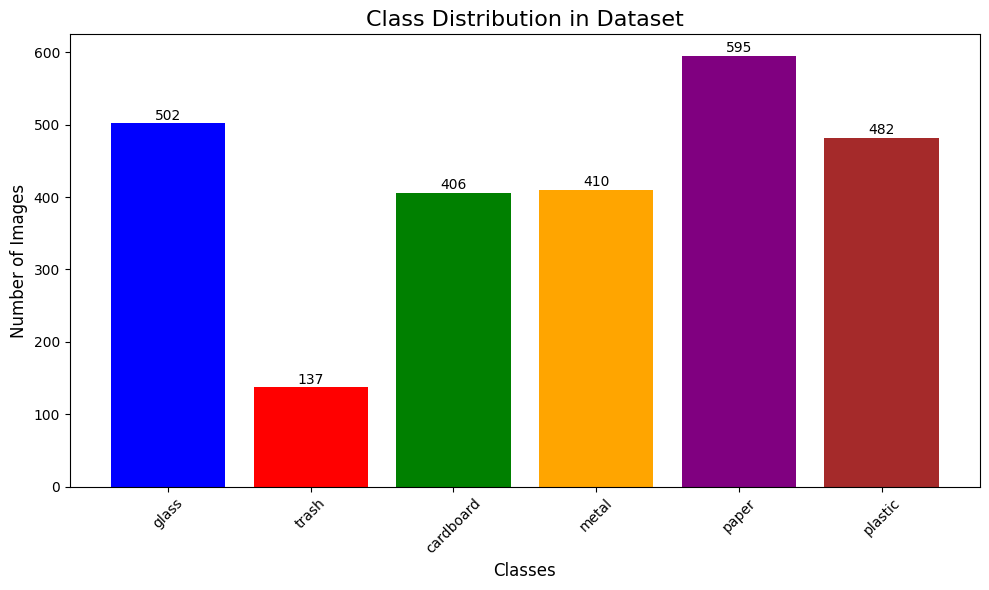

Total images: 2532
Average images per class: 422.00
Smallest class: trash with 137 images
Largest class: paper with 595 images
Class imbalance ratio: 4.34:1


In [7]:
# Class distribution visualize karte hain
plt.figure(figsize=(10, 6))

# Class names aur counts ko sort karte hain
class_names = ['glass', 'trash', 'cardboard', 'metal', 'paper', 'plastic']
counts = [502, 137, 406, 410, 595, 482]

# Bar plot
plt.bar(class_names, counts, color=['blue', 'red', 'green', 'orange', 'purple', 'brown'])
plt.title('Class Distribution in Dataset', fontsize=16)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)

# Count values bar ke upar display karte hain
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Statistics
print(f"Total images: {sum(counts)}")
print(f"Average images per class: {sum(counts)/len(counts):.2f}")
print(f"Smallest class: {class_names[counts.index(min(counts))]} with {min(counts)} images")
print(f"Largest class: {class_names[counts.index(max(counts))]} with {max(counts)} images")
print(f"Class imbalance ratio: {max(counts)/min(counts):.2f}:1")

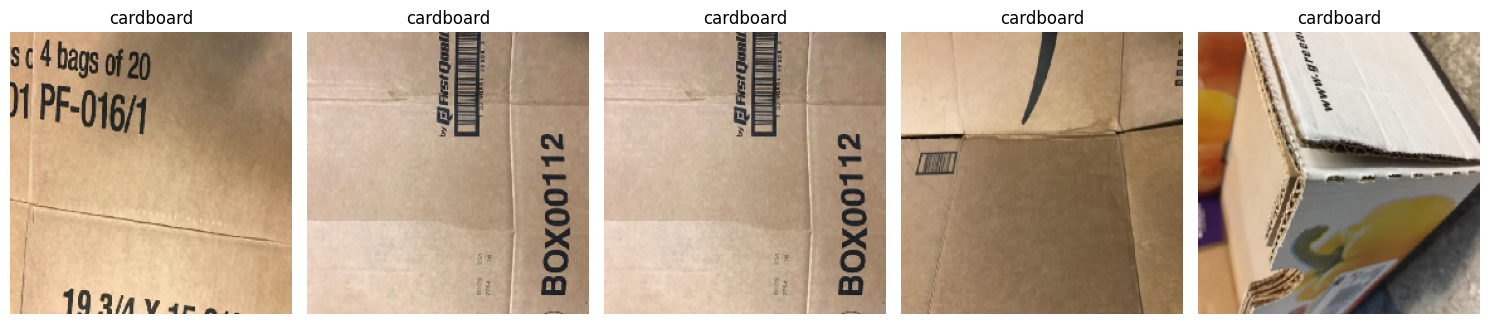

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

def show_random_samples(num_samples=5):
    images, labels = next(dataset)   # Get one batch

    plt.figure(figsize=(15, 5))

    for i in range(num_samples):
        idx = random.randint(0, len(images)-1)

        img = images[idx]
        label = np.argmax(labels[idx])   # Convert one-hot to class index
        class_name = list(dataset.class_indices.keys())[label]

        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_samples(5)

In [10]:
classes = sorted(os.listdir(data_dir))
print("Sorted classes:", classes)

Sorted classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


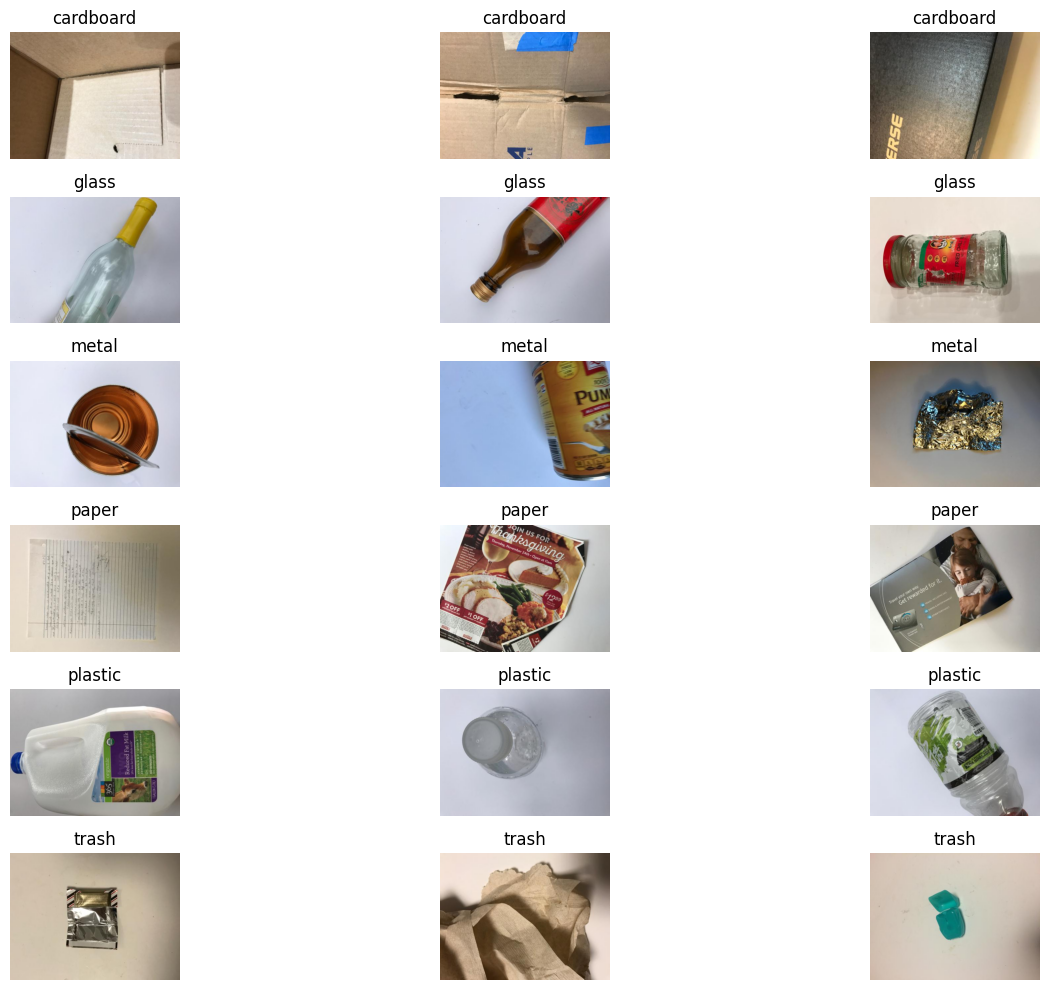

In [13]:
# Sample images display karne ke liye function
def display_sample_images(data_dir, classes, num_samples=3):
    plt.figure(figsize=(15, 10))

    for idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        images = os.listdir(class_path)[:num_samples]  # Har class se 3 images

        for i, img_name in enumerate(images):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(classes), num_samples, idx * num_samples + i + 1)
            plt.imshow(img)
            plt.title(f"{class_name}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Sample images display karte hain
display_sample_images(data_dir, classes)

Image Size Statistics:
Min height: 384, Max height: 384
Min width: 512, Max width: 512
Average height: 384.00
Average width: 512.00


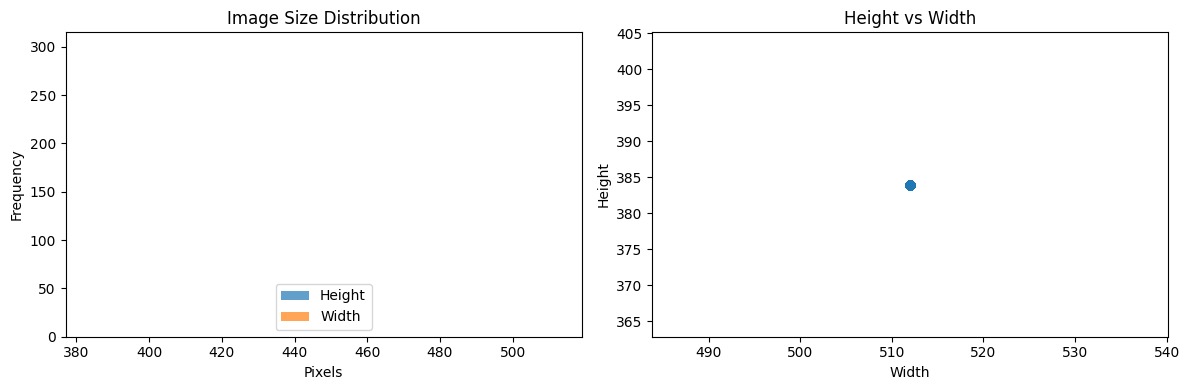

In [ ]:
# Image sizes analyze karte hain
def analyze_image_sizes(data_dir, classes):
    sizes = []
    class_sizes = {class_name: [] for class_name in classes}

    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        images = os.listdir(class_path)[:50]  # Har class se 50 images

        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                sizes.append((h, w))
                class_sizes[class_name].append((h, w))

    # Convert to DataFrame for analysis
    sizes_df = pd.DataFrame(sizes, columns=['height', 'width'])

    print("Image Size Statistics:")
    print(f"Min height: {sizes_df['height'].min()}, Max height: {sizes_df['height'].max()}")
    print(f"Min width: {sizes_df['width'].min()}, Max width: {sizes_df['width'].max()}")
    print(f"Average height: {sizes_df['height'].mean():.2f}")
    print(f"Average width: {sizes_df['width'].mean():.2f}")

    # Size distribution plot
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(sizes_df['height'], bins=20, alpha=0.7, label='Height')
    plt.hist(sizes_df['width'], bins=20, alpha=0.7, label='Width')
    plt.xlabel('Pixels')
    plt.ylabel('Frequency')
    plt.title('Image Size Distribution')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(sizes_df['width'], sizes_df['height'], alpha=0.5)
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.title('Height vs Width')

    plt.tight_layout()
    plt.show()

    return sizes_df

# Image sizes analyze karte hain
sizes_df = analyze_image_sizes(data_dir, classes)

##  STEP 3: Data Preprocessing & Augmentation

In [ ]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# STEP 3: Data Preprocessing & Augmentation

from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Class indices:", train_generator.class_indices)

Found 2027 images belonging to 6 classes.
Found 505 images belonging to 6 classes.
Training samples: 2027
Validation samples: 505
Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## Step 4: Compute Class Weights

In [ ]:
# STEP 4: Handle Class Imbalance using Class Weights

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from training generator
labels = train_generator.classes

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convert to dictionary format
class_weights = dict(enumerate(class_weights))

print("Class Weights:")
for k, v in class_weights.items():
    print(f"Class {k} ({list(train_generator.class_indices.keys())[k]}): {v:.2f}")

Class Weights:
Class 0 (cardboard): 1.04
Class 1 (glass): 0.84
Class 2 (metal): 1.03
Class 3 (paper): 0.71
Class 4 (plastic): 0.88
Class 5 (trash): 3.07


## STEP 5: Transfer Learning Model (EfficientNetB0)

In [ ]:
# STEP 5: Build EfficientNetB0 Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,384,169 (16.72 MB)

 Trainable params: 332,038 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## STEP 6: Train EfficientNet (Feature Extraction Phase)

In [ ]:
# STEP 6: Train EfficientNet (Feature Extraction Phase)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficientnet.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

## Load Best Model

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("best_efficientnet.keras")
print("Best model loaded successfully!")

## STEP 9: Final Evaluation

In [ ]:
# Classification Report
from sklearn.metrics import classification_report
import numpy as np

val_generator.reset()
preds = model.predict(val_generator)
y_pred = np.argmax(preds, axis=1)

print(classification_report(
    val_generator.classes,
    y_pred,
    target_names=list(val_generator.class_indices.keys())
))

16/16 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step
              precision    recall  f1-score   support

   cardboard       0.97      0.78      0.86        81
       glass       0.80      0.86      0.83       100
       metal       0.80      0.85      0.82        82
       paper       0.87      0.93      0.90       119
     plastic       0.87      0.71      0.78        96
       trash       0.50      0.74      0.60        27

    accuracy                           0.83       505
   macro avg       0.80      0.81      0.80       505
weighted avg       0.84      0.83      0.83       505



## Plot Training vs Validation Curves

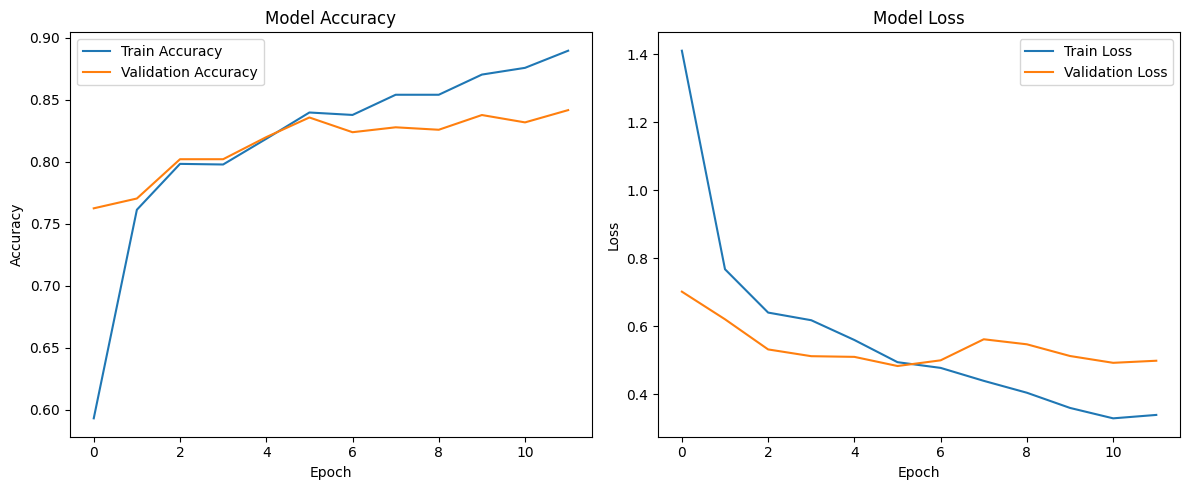

In [ ]:
# Plot Accuracy & Loss Curves

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Confusion Matrix

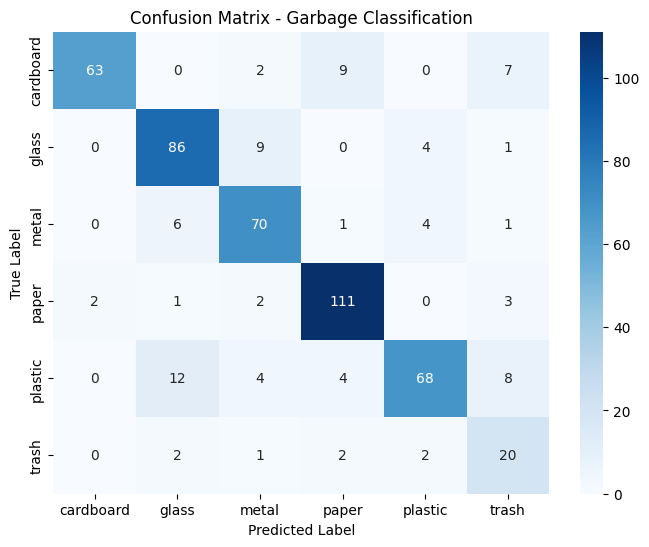

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(val_generator.class_indices.keys()),
    yticklabels=list(val_generator.class_indices.keys())
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Garbage Classification")
plt.show()

## Save Final Model

In [ ]:
model.save("RecycleVision_EfficientNetB0_Final.keras")
print("Model saved locally as: RecycleVision_EfficientNetB0_Final.keras")

In [ ]:
model.save("/content/drive/MyDrive/RecycleVision_Project/RecycleVision_Final_Model.keras")
print("Model saved to Google Drive: /content/drive/MyDrive/RecycleVision_Project/RecycleVision_Final_Model.keras")

In [ ]:
# This is desktop setup
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

# Class names (important)
class_names = list(train_generator.class_indices.keys())

def predict_image(img_path):

    # Read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to model input size
    img_resized = cv2.resize(img, (224, 224))

    # Convert to array
    img_array = np.array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocess for EfficientNet
    img_array = preprocess_input(img_array)

    # Prediction
    preds = model.predict(img_array)
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    # Show image
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print("Prediction:", predicted_class)
    print("Confidence:", f"{confidence:.2f}%")

In [ ]:
from google.colab import files  # desktop setup
uploaded = files.upload()

Saving white-crumpled-paper-texture-background-white-old-creased-and-wrinkled-paper-abstract-background-grunge-texture-surface-paper-page-material-for-vintage-design-manuscript-letter-paper-white-sheet-photo.jpeg to white-crumpled-paper-texture-background-white-old-creased-and-wrinkled-paper-abstract-background-grunge-texture-surface-paper-page-material-for-vintage-design-manuscript-letter-paper-white-sheet-photo.jpeg


In [ ]:
# Direct Google Setup (Images)
import requests
from PIL import Image
from io import BytesIO
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input

def predict_from_url(url):

    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    img = np.array(img)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)
    predicted_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.axis("off")
    plt.show()

    print("Prediction:", predicted_class)
    print("Confidence:", f"{confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


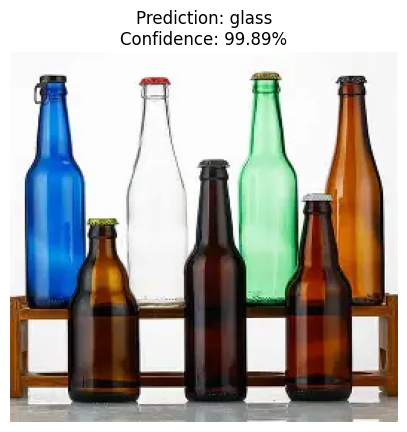

Prediction: glass
Confidence: 99.89%


In [ ]:
# Direct Google Setup Images
predict_from_url("https://th.bing.com/th/id/OIP.v9M_jELxsxPVWtstylrxxQHaHG?w=201&h=192&c=7&r=0&o=7&dpr=1.3&pid=1.7&rm=3")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


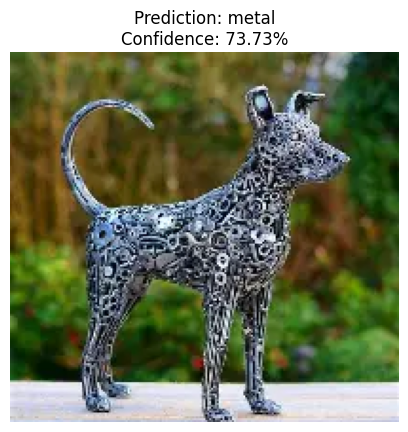

Prediction: metal
Confidence: 73.73%


In [ ]:
predict_from_url("https://th.bing.com/th/id/OIP.cqg8c5aNZPA27LWJDYHsgwHaHa?w=158&h=150&c=6&o=7&dpr=1.3&pid=1.7&rm=3")